# AA-CLIP: Medical Image Anomaly Detection — fine-tune with before/after evaluation

This notebook runs **[Medical-Image-Anomaly-Detection](https://github.com/Jinali-Shah5/Medical-Image-Anomaly-Detection)**
(a fork of **AA-CLIP: Enhancing Zero-shot Anomaly Detection via Anomaly-Aware CLIP**, CVPR 2025)
end-to-end on Google Colab, structured as a proper **before → fine-tune → after** experiment:

| Stage | What runs | What it measures |
|---|---|---|
| **1. BEFORE** | Zero-shot **frozen CLIP** (no adapters, raw CLIP text prompts) on all 3 polyp datasets | The pre-fine-tuning baseline |
| **2. Fine-tune** | Two-stage adapter training (text adapter → image adapter) on **`Colon_clinicDB`** | The actual fine-tuning (CLIP backbone stays frozen; only lightweight adapters train) |
| **3. AFTER** | The fine-tuned model on the same 3 datasets with the same metrics | The gain from fine-tuning |
| **4. Compare** | Before/after table with Δ + bar chart + side-by-side heatmaps | Your headline result |

**Evaluation protocol (important for reporting):** adapters are trained on `Colon_clinicDB` only.
- `Colon_clinicDB` after-scores are **in-domain** — the repo uses the same image list for train and test, so treat that row as a sanity check, not a claim.
- `Colon_colonDB` and `Colon_Kvasir` are **never seen during training** — improvements there are genuine zero-shot **generalization** gains, which is exactly the claim the AA-CLIP paper makes. Lead with these numbers.

**Metrics:** the bundled polyp datasets contain *only anomalous images* (every image has a polyp, label=1), so image-level AUC/AP are degenerate (always 0). The meaningful metrics are **pixel AUC** and **pixel AP** (anomaly *localization*).

**Before you start:** `Runtime → Change runtime type → T4 GPU` (or better).

> `MVTec`, `VisA`, `MPDD`, `BTAD`, `Brain`, `Liver`, and `Retina` are **not** included in the repo (separate downloads per the original README). This notebook uses the three datasets that ship with the repo: `Colon_clinicDB` (612 imgs), `Colon_colonDB` (380), `Colon_Kvasir` (1000).

## 1. Check GPU

In [1]:
!nvidia-smi

Tue Aug 11 17:39:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the repository

If you'd rather work on your own copy, fork the repo first and change the URL below.

In [2]:
import os

REPO_URL = "https://github.com/Jinali-Shah5/Medical-Image-Anomaly-Detection.git"
REPO_DIR = "/content/Medical-Image-Anomaly-Detection"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned.")

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

Cloning into '/content/Medical-Image-Anomaly-Detection'...
remote: Enumerating objects: 4045, done.
remote: Total 4045 (delta 0), reused 0 (delta 0), pack-reused 4045 (from 1)
Receiving objects: 100% (4045/4045), 538.59 MiB | 36.97 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Updating files: 100% (4020/4020), done.
Working directory: /content/Medical-Image-Anomaly-Detection


## 3. Install dependencies

In [3]:
# Colab already ships torch/torchvision with CUDA, jupyter, and ipykernel,
# so we skip those lines from requirements.txt to avoid an unnecessary reinstall.
!grep -Ev '^(torch|torchvision|torchaudio|jupyter|notebook|ipykernel)([=<>~ ]|$)' requirements.txt > /content/requirements_colab.txt
!pip install -q -r /content/requirements_colab.txt

# The repo pins opencv-python==4.9.0.80, which was built against NumPy 1.x.
# Colab ships NumPy 2.0.2, which breaks that build of cv2 ("_ARRAY_API not found").
# Upgrade opencv-python to a build that supports NumPy 2 instead:
!pip install -q -U "opencv-python>=4.10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.1/569.1 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
prettytable 3.18.0 requires wcwidth>=0.

## 4. Download the CLIP ViT-L-14-336px backbone

The model expects `model/ViT-L-14-336px.pt` (OpenAI's original CLIP checkpoint, ~890MB).

In [4]:
import os

CKPT_PATH = "model/ViT-L-14-336px.pt"
CKPT_URL = "https://openaipublic.azureedge.net/clip/models/3035c92b350959924f9f00213499208652fc7ea050643e8b385c2dac08641f02/ViT-L-14-336px.pt"

if not os.path.exists(CKPT_PATH):
    !wget -q --show-progress -O {CKPT_PATH} {CKPT_URL}
else:
    print("Checkpoint already present.")

print("Size (MB):", os.path.getsize(CKPT_PATH) / 1e6)

model/ViT-L-14-336p 100%[===================>] 890.82M  77.9MB/s    in 14s     
Size (MB): 934.08868


## 5. Point the dataset config at the bundled data

`dataset/constants.py` hard-codes `BASE_PATH = "/data/wenxinma"` (the original author's machine).

Because training/testing run as **separate `!python train.py` subprocesses** (not in this notebook's own
Python process), patching the `DATA_PATH` dict in memory here has no effect on them — the subprocess
just re-imports the original file from disk. So instead we edit `dataset/constants.py` on disk, appending
overrides that point the three bundled polyp datasets at their real location in the repo:

- `Colon_clinicDB` -> `dataset/CVC-ClinicDB`
- `Colon_colonDB`  -> `dataset/CVC-ColonDB`
- `Colon_Kvasir`   -> `dataset/Kvasir`

If you later add MVTec/VisA/etc., upload them under `./data/<name>` and append similar override lines.

In [5]:
import os
import dataset.constants as constants  # reload after edit, just to sanity-check below

REPO_ROOT = os.getcwd()
CONSTANTS_PATH = "dataset/constants.py"

MARKER = "# --- Colab path overrides (added by notebook) ---"

overrides = f'''
{MARKER}
DATA_PATH["Colon_clinicDB"] = "{REPO_ROOT}/dataset/CVC-ClinicDB"
DATA_PATH["Colon_colonDB"] = "{REPO_ROOT}/dataset/CVC-ColonDB"
DATA_PATH["Colon_Kvasir"] = "{REPO_ROOT}/dataset/Kvasir"
'''

with open(CONSTANTS_PATH, "r") as f:
    contents = f.read()

if MARKER not in contents:
    with open(CONSTANTS_PATH, "a") as f:
        f.write(overrides)
    print("Appended path overrides to", CONSTANTS_PATH)
else:
    print("Overrides already present in", CONSTANTS_PATH)

# Sanity check by importing fresh (as a subprocess would)
!python -c "from dataset.constants import DATA_PATH; import os; [print(k, '->', v, '| exists:', os.path.isdir(v)) for k, v in DATA_PATH.items() if k.startswith('Colon')]"

Appended path overrides to dataset/constants.py
Colon_clinicDB -> /content/Medical-Image-Anomaly-Detection/dataset/CVC-ClinicDB | exists: True
Colon_colonDB -> /content/Medical-Image-Anomaly-Detection/dataset/CVC-ColonDB | exists: True
Colon_cvc300 -> /data/wenxinma/data/Colon/CVC-300 | exists: False
Colon_Kvasir -> /content/Medical-Image-Anomaly-Detection/dataset/Kvasir | exists: True


## 6. Apply small code patches

Two safe, re-runnable patches to the repo (originals are backed up as `.bak`):

1. **`test.py` pandas fix** — the repo's `df.mean()` on a mixed-type DataFrame breaks on modern pandas. Only matters if you use the repo's own `test.py`; our `evaluate.py` (Section 8) avoids the bug, but we patch anyway so `test.py` stays usable.
2. **`forward_utils.py` visualization fix** — `visualize()` only built filenames for MVTec (raised `NotImplementedError` for the polyp datasets) and had an RGB/BGR mixup. **This one is required** for the heatmaps in Sections 9/11/13.

In [6]:
# ============================================================
# PATCH: fix pandas 2/3 incompatibility in test.py
# Run ONCE, before the test/evaluate cells. Safe to re-run.
# ============================================================
import os

REPO_DIR = "/content/Medical-Image-Anomaly-Detection"

if not os.path.isdir(REPO_DIR):
    raise FileNotFoundError(
        f"{REPO_DIR} not found — the Colab VM was recycled. "
        "Re-run the notebook from the 'Clone the repository' cell."
    )
os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

OLD = '''        df.loc[len(df)] = df.mean()
        df.loc[len(df) - 1]["class name"] = "Average"'''

NEW = '''        import pandas as _pd
        _num = df.drop(columns=["class name"]).apply(_pd.to_numeric, errors="coerce")
        df.loc[len(df)] = {"class name": "Average", **_num.mean().round(2).to_dict()}'''

with open("test.py") as f:
    src = f.read()

if NEW in src:
    print("Already patched — nothing to do.")
elif OLD in src:
    with open("test.py.bak", "w") as f:      # backup of the original
        f.write(src)
    with open("test.py", "w") as f:
        f.write(src.replace(OLD, NEW))
    print("Patched test.py (original saved as test.py.bak)")
else:
    raise RuntimeError(
        "Couldn't find the expected code in test.py — check lines ~247-248 manually."
    )

# Make sure the patched file is still valid Python before running it
import py_compile
py_compile.compile("test.py", doraise=True)
print("test.py compiles cleanly — you can run the test cells now.")

print("\n--- patched region ---")
print("\n".join(open("test.py").read().split("\n")[244:250]))

# Do the heatmaps already exist from the earlier run?
_ds = globals().get("DATASET", "Colon_clinicDB")
_vis = f"ckpt/{_ds}/visualization"
if os.path.isdir(_vis):
    _n = sum(len([f for f in fs if f.endswith(".png")]) for _, _, fs in os.walk(_vis))
    print(f"\nNote: {_n} visualization PNGs already exist under {_vis}")
else:
    print(f"\nNo visualizations yet at {_vis} — cell 9 will create them.")

Working directory: /content/Medical-Image-Anomaly-Detection
Patched test.py (original saved as test.py.bak)
test.py compiles cleanly — you can run the test cells now.

--- patched region ---
            )
            df.loc[len(df)] = Series(class_result_dict)
        import pandas as _pd
        _num = df.drop(columns=["class name"]).apply(_pd.to_numeric, errors="coerce")
        df.loc[len(df)] = {"class name": "Average", **_num.mean().round(2).to_dict()}
        logger.info("final results:\n%s", df.to_string(index=False, justify="center"))

No visualizations yet at ckpt/Colon_clinicDB/visualization — cell 9 will create them.


In [7]:
import os

REPO_DIR = "/content/Medical-Image-Anomaly-Detection"
if not os.path.isdir(REPO_DIR):
    raise FileNotFoundError(f"{REPO_DIR} not found — re-run from the clone cell.")
os.chdir(REPO_DIR)

with open("forward_utils.py") as f:
    src = f.read()

# --- Fix 1: visualize() only builds filenames for MVTec, raises otherwise ---
OLD_NAME = '''        if dataset_name == "MVTec":
            damage_name, image_name = file.split("/")[-2:]
            file_name = f"{damage_name}_{image_name}"
        else:
            raise NotImplementedError'''

NEW_NAME = '''        file_name = "_".join(file.split("/")[-2:]) if "/" in file else file'''

# --- Fix 2: image converted to RGB but written with cv2.imwrite (expects BGR),
#            which swaps red and blue. Stay in BGR throughout. ---
OLD_COLOR = "        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)"
NEW_COLOR = "        # (kept in BGR: cv2.imwrite expects BGR)"

changed = []

if NEW_NAME in src:
    print("Fix 1 (filename): already applied.")
elif OLD_NAME in src:
    src = src.replace(OLD_NAME, NEW_NAME)
    changed.append("filename")
else:
    raise RuntimeError("Fix 1: expected MVTec block not found in forward_utils.py")

if NEW_COLOR in src:
    print("Fix 2 (color order): already applied.")
elif OLD_COLOR in src:
    src = src.replace(OLD_COLOR, NEW_COLOR)
    changed.append("color order")
else:
    print("Fix 2: BGR2RGB line not found — skipping.")

if changed:
    if not os.path.exists("forward_utils.py.bak"):
        with open("forward_utils.py.bak", "w") as f:
            f.write(open("forward_utils.py").read())
    with open("forward_utils.py", "w") as f:
        f.write(src)
    print("Patched forward_utils.py:", ", ".join(changed))

import py_compile
py_compile.compile("forward_utils.py", doraise=True)
print("forward_utils.py compiles cleanly.")

lines = open("forward_utils.py").read().split("\n")
start = next(i for i, l in enumerate(lines) if l.startswith("def visualize("))
print("\n--- patched visualize() ---")
print("\n".join(lines[start:start + 32]))

Patched forward_utils.py: filename, color order
forward_utils.py compiles cleanly.

--- patched visualize() ---
def visualize(
    pixel_label: np.ndarray,
    pixel_preds: np.ndarray,
    file_names: list[str],
    save_dir: str,
    dataset_name: str,
    class_name: str,
):
    if pixel_preds.max() != 1:
        pixel_preds = (pixel_preds - pixel_preds.min()) / (
            pixel_preds.max() - pixel_preds.min()
        )
        pixel_preds = (pixel_preds * 255).astype(np.uint8)
    if pixel_label.dtype != np.uint8:
        pixel_label = pixel_label != 0
        pixel_label = (pixel_label * 255).astype(np.uint8)
    # ===============================================================================================
    # save path
    save_dir = os.path.join(save_dir, "visualization", dataset_name, class_name)
    os.makedirs(save_dir, exist_ok=True)
    for idx, file in enumerate(file_names):
        image_file = os.path.join(DATA_PATH[dataset_name], file)
        image = cv2.imread(

## 7. Choose training dataset and evaluation datasets

Adapters are fine-tuned on `TRAIN_DATASET`; **before** and **after** evaluations run on every dataset in `EVAL_DATASETS`, so you get both in-domain and cross-dataset (generalization) numbers.

In [8]:
import os

TRAIN_DATASET = "Colon_clinicDB"   # adapters are fine-tuned on this dataset only
EVAL_DATASETS = ["Colon_clinicDB", "Colon_colonDB", "Colon_Kvasir"]

DATASET = TRAIN_DATASET            # kept for compatibility with the training cell below
SAVE_PATH = f"./ckpt/{TRAIN_DATASET}"
RESULTS_DIR = "./results_before_after"
VIS_LIMIT = 12                     # heatmaps saved per mode (on TRAIN_DATASET only)

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Train on:", TRAIN_DATASET, "| Evaluate on:", EVAL_DATASETS)

Train on: Colon_clinicDB | Evaluate on: ['Colon_clinicDB', 'Colon_colonDB', 'Colon_Kvasir']


## 8. Write the unified evaluation script (`evaluate.py`)

One script, two modes, **identical metrics pipeline** — so before/after numbers are directly comparable:

- `--mode zero_shot` (**BEFORE**): frozen CLIP only. Image features come from the repo's `AdaptedCLIP.forward_original()` (original CLIP projection, no adapters) and text anchors from raw CLIP `encode_text`. Needs no trained weights — this is what CLIP can do on polyps out of the box.
- `--mode adapted` (**AFTER**): loads `text_adapter.pth` + `image_adapter.pth` from `--ckpt_path` and runs the adapted forward pass — the same math as the repo's `test.py`, but a single pass over the final checkpoint instead of one full evaluation per saved epoch (the repo's `test.py` re-evaluates every `image_adapter_*.pth`, i.e. ~10 full passes).

Both modes reuse the repo's own `calculate_similarity_map` and `metrics_eval`, print a results table, and write a CSV to `--out_csv`. `--vis_dir` optionally dumps heatmap overlays (needs the Section 6 patch). Pixel AUC/AP are rank-based, so the unscaled zero-shot similarity scores compare fairly against the trained model.

In [9]:
%%writefile evaluate.py
"""Unified BEFORE/AFTER evaluation for AA-CLIP.

Two modes, identical metrics, so the comparison is apples-to-apples:

  --mode zero_shot   BEFORE fine-tuning. Frozen CLIP only: image features come
                     from AdaptedCLIP.forward_original() (no adapters, original
                     CLIP projection) and text anchors from raw CLIP encode_text.
                     Needs no trained checkpoints.

  --mode adapted     AFTER fine-tuning. Loads text_adapter.pth and
                     image_adapter.pth from --ckpt_path and runs the adapted
                     forward pass (same math as the repo's test.py, but a single
                     pass over the final checkpoint instead of one per epoch).

Prints a results table and writes it to --out_csv. Optionally dumps heatmap
visualizations with --vis_dir (requires the forward_utils.py patch cell from
the notebook to have been run first, for non-MVTec filenames).

Metrics note: the bundled polyp datasets contain only anomalous images
(label=1 for every sample), so image-level AUC/AP are degenerate (reported
as 0 by metrics_eval). The meaningful numbers here are pixel AUC / pixel AP
(anomaly localization).
"""

import argparse
import os
import warnings

import numpy as np
import torch
import torch.nn.functional as F
from pandas import DataFrame
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import DOMAINS, get_dataset
from forward_utils import (
    calculate_similarity_map,
    get_adapted_text_embedding,
    metrics_eval,
    visualize,
)
from model.adapter import AdaptedCLIP
from model.clip import create_model
from utils import setup_seed

warnings.filterwarnings("ignore")


def build_model(args, device):
    clip_model = create_model(
        model_name=args.model_name,
        img_size=args.img_size,
        device=device,
        pretrained="openai",
        require_pretrained=True,
    )
    clip_model.eval()
    model = AdaptedCLIP(
        clip_model=clip_model,
        text_adapt_weight=args.text_adapt_weight,
        image_adapt_weight=args.image_adapt_weight,
        text_adapt_until=args.text_adapt_until,
        image_adapt_until=args.image_adapt_until,
        relu=args.relu,
    ).to(device)
    model.eval()
    return clip_model, model


def load_adapters(model, ckpt_path, device):
    text_ckpt = os.path.join(ckpt_path, "text_adapter.pth")
    image_ckpt = os.path.join(ckpt_path, "image_adapter.pth")
    assert os.path.isfile(text_ckpt), f"missing {text_ckpt} - run training first"
    assert os.path.isfile(image_ckpt), f"missing {image_ckpt} - run training first"
    tc = torch.load(text_ckpt, map_location=device)
    model.text_adapter.load_state_dict(tc["text_adapter"])
    ic = torch.load(image_ckpt, map_location=device)
    model.image_adapter.load_state_dict(ic["image_adapter"])
    print(f"[adapted] loaded adapters from {ckpt_path} "
          f"(text epoch {tc.get('epoch', '?')}, image epoch {ic.get('epoch', '?')})")


@torch.no_grad()
def run_class(model, mode, loader, t_emb, img_size, domain, desc):
    masks, labels, preds, preds_image, file_names = [], [], [], [], []
    for batch in tqdm(loader, desc=desc):
        image = batch["image"].to(next(model.parameters()).device)
        masks.append(batch["mask"].numpy())
        labels.append(np.asarray(batch["label"], dtype=np.float32))
        file_names.extend(batch["file_name"])

        if mode == "adapted":
            # adapted forward returns L2-normalized multi-level patch tokens + det token
            patch_feats, det = model(image)
        else:
            # frozen CLIP: original projection, single level; normalize for cosine sim
            patch_feats, det = model.forward_original(image)
            patch_feats = [F.normalize(f, dim=-1) for f in patch_feats]
            det = F.normalize(det, dim=-1)

        img_score = ((det @ t_emb)[:, 1] + 1) / 2
        preds_image.append(img_score.cpu().numpy())

        level_preds = [
            calculate_similarity_map(f, t_emb, img_size, test=True, domain=domain)
            for f in patch_feats
        ]
        preds.append(torch.cat(level_preds, dim=1).sum(1).cpu().numpy())

    return (
        np.concatenate(masks, axis=0),
        np.concatenate(labels, axis=0),
        np.concatenate(preds, axis=0),
        np.concatenate(preds_image, axis=0),
        file_names,
    )


def main():
    p = argparse.ArgumentParser(description="AA-CLIP before/after evaluation")
    p.add_argument("--mode", choices=["zero_shot", "adapted"], required=True)
    p.add_argument("--dataset", type=str, required=True)
    p.add_argument("--out_csv", type=str, required=True)
    p.add_argument("--ckpt_path", type=str, default=None,
                   help="dir with text_adapter.pth / image_adapter.pth (adapted mode)")
    p.add_argument("--model_name", type=str, default="ViT-L-14-336")
    p.add_argument("--img_size", type=int, default=336)
    p.add_argument("--batch_size", type=int, default=8)
    p.add_argument("--seed", type=int, default=111)
    p.add_argument("--vis_dir", type=str, default=None,
                   help="if set, save heatmap visualizations under this dir")
    p.add_argument("--vis_limit", type=int, default=24,
                   help="max images to visualize per class (0 = all)")
    # adapter hyperparameters - must match the values used in training
    p.add_argument("--relu", action="store_true")
    p.add_argument("--text_adapt_weight", type=float, default=0.1)
    p.add_argument("--image_adapt_weight", type=float, default=0.1)
    p.add_argument("--text_adapt_until", type=int, default=3)
    p.add_argument("--image_adapt_until", type=int, default=6)
    args = p.parse_args()

    setup_seed(args.seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"[{args.mode}] dataset={args.dataset} img_size={args.img_size} device={device}")

    clip_model, model = build_model(args, device)
    if args.mode == "adapted":
        assert args.ckpt_path, "--ckpt_path is required for --mode adapted"
        load_adapters(model, args.ckpt_path, device)

    # text anchors: raw CLIP text for the zero-shot baseline, adapted text after fine-tuning
    with torch.no_grad():
        text_model = model if args.mode == "adapted" else clip_model
        text_embeddings = get_adapted_text_embedding(text_model, args.dataset, device)

    image_datasets = get_dataset(args.dataset, args.img_size, None, 0, "test", logger=None)
    kwargs = {"num_workers": 2, "pin_memory": True} if torch.cuda.is_available() else {}

    rows = []
    for class_name, ds in image_datasets.items():
        loader = DataLoader(ds, batch_size=args.batch_size, shuffle=False, **kwargs)
        masks, labels, preds, preds_image, file_names = run_class(
            model, args.mode, loader, text_embeddings[class_name],
            args.img_size, DOMAINS[args.dataset],
            desc=f"{args.mode}:{args.dataset}:{class_name}",
        )
        if args.vis_dir:
            n = args.vis_limit if args.vis_limit and args.vis_limit > 0 else len(file_names)
            visualize(masks[:n], preds[:n], file_names[:n],
                      args.vis_dir, args.dataset, class_name)
            print(f"saved {min(n, len(file_names))} visualizations under "
                  f"{os.path.join(args.vis_dir, 'visualization', args.dataset, class_name)}")
        rows.append(metrics_eval(masks, labels, preds, preds_image,
                                 class_name, DOMAINS[args.dataset]))

    df = DataFrame(rows)
    numeric = df.drop(columns=["class name"]).astype(float)
    df.loc[len(df)] = {"class name": "Average", **numeric.mean().round(2).to_dict()}
    df.insert(0, "mode", args.mode)
    df.insert(1, "dataset", args.dataset)

    out_dir = os.path.dirname(args.out_csv)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    df.to_csv(args.out_csv, index=False)
    print(df.to_string(index=False))
    print(f"saved -> {args.out_csv}")


if __name__ == "__main__":
    main()


Writing evaluate.py


## 9. Evaluate BEFORE fine-tuning — zero-shot CLIP baseline

Runs the frozen-CLIP baseline on all evaluation datasets (~1–2 min each on a T4; no training needed). Heatmaps are saved for `TRAIN_DATASET` so Section 13 can show before/after side by side.

In [10]:
for ds in EVAL_DATASETS:
    vis = f"--vis_dir {RESULTS_DIR}/vis_zero_shot --vis_limit {VIS_LIMIT}" if ds == TRAIN_DATASET else ""
    !python evaluate.py \
        --mode zero_shot \
        --dataset {ds} \
        --img_size 336 \
        --batch_size 8 \
        --out_csv {RESULTS_DIR}/zero_shot_{ds}.csv \
        {vis}

[zero_shot] dataset=Colon_clinicDB img_size=336 device=cuda:0
zero_shot:Colon_clinicDB:Colon_clinicDB: 100% 77/77 [01:17<00:00,  1.01s/it]
saved 12 visualizations under ./results_before_after/vis_zero_shot/visualization/Colon_clinicDB/Colon_clinicDB
     mode        dataset     class name  pixel AUC  pixel AP  image AUC  image AP
zero_shot Colon_clinicDB Colon_clinicDB      65.14     23.36        0.0       0.0
zero_shot Colon_clinicDB        Average      65.14     23.36        0.0       0.0
saved -> ./results_before_after/zero_shot_Colon_clinicDB.csv
[zero_shot] dataset=Colon_colonDB img_size=336 device=cuda:0
zero_shot:Colon_colonDB:Colon_colonDB: 100% 48/48 [00:52<00:00,  1.10s/it]
     mode       dataset    class name  pixel AUC  pixel AP  image AUC  image AP
zero_shot Colon_colonDB Colon_colonDB      70.99     22.45        0.0       0.0
zero_shot Colon_colonDB       Average      70.99     22.45        0.0       0.0
saved -> ./results_before_after/zero_shot_Colon_colonDB.csv
[zero_s

In [11]:
import glob
import pandas as pd

before = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(f"{RESULTS_DIR}/zero_shot_*.csv"))],
    ignore_index=True,
)
print("BEFORE fine-tuning (zero-shot CLIP) — pixel metrics are the meaningful ones:")
before[before["class name"] != "Average"].reset_index(drop=True)

BEFORE fine-tuning (zero-shot CLIP) — pixel metrics are the meaningful ones:


,mode,dataset,class name,pixel AUC,pixel AP,image AUC,image AP
0,zero_shot,Colon_Kvasir,Kvasir,67.56,34.54,0.0,0.0
1,zero_shot,Colon_clinicDB,Colon_clinicDB,65.14,23.36,0.0,0.0
2,zero_shot,Colon_colonDB,Colon_colonDB,70.99,22.45,0.0,0.0


## 10. Fine-tune the adapters

This runs the two-stage adapter training (text adapter, then image adapter) from `train.py`.
`training_mode full_shot` uses all available images; switch to `few_shot --shot N` for a quicker run.

**Speed settings below are tuned for these small datasets (380-999 images):**
- `--image_batch_size 2` — the repo's original default. `16` and `8` both hit CUDA out-of-memory on a
  T4 (14.6GB): the two full ViT-L/14 copies (`clip_surgery` + `clip_model`) plus optimizer state already
  use nearly the entire GPU before batch size is even a factor, so there's very little headroom to push
  batch size up on this hardware. `2` is the safe, tested value.
- `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` — reduces memory lost to fragmentation, which
  matters a lot this close to the memory ceiling (PyTorch's own OOM message suggested this).
- `--image_epoch 10` (repo default is 20) — small, fairly homogeneous datasets tend to converge faster
  than the paper's original VisA setup. Watch the per-epoch loss; lower further next run if it plateaus early.
- `--img_size 336` (repo default is 518) — matches the CLIP backbone's native resolution, cutting
  per-image compute. Trade-off: coarser anomaly localization on small features. **`test.py` calls later
  in this notebook also pass `--img_size 336` to match — keep these in sync if you change it.**

**Good to know: `train.py` auto-resumes.** It looks in `--save_path` for `text_adapter.pth` and
`image_adapter.pth` and picks up from the last *completed* epoch of each stage. So if Stage 2 OOMs,
re-running will skip Stage 1 (already saved) and retry Stage 2 from scratch — it won't redo the text adapter.

If you want a bigger GPU instead of a smaller batch size, switch to an A100/L4 runtime in
`Runtime -> Change runtime type` (Colab Pro) — that removes the memory pressure causing these OOMs entirely.

In [12]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!python train.py \
    --dataset {DATASET} \
    --training_mode full_shot \
    --save_path {SAVE_PATH} \
    --text_epoch 5 \
    --image_epoch 10 \
    --image_batch_size 2 \
    --img_size 336

100% 39/39 [03:01<00:00,  4.65s/it]
100% 39/39 [02:58<00:00,  4.59s/it]
100% 39/39 [02:58<00:00,  4.57s/it]
100% 39/39 [02:58<00:00,  4.58s/it]
100% 39/39 [02:58<00:00,  4.58s/it]
100% 306/306 [04:19<00:00,  1.18it/s]
100% 306/306 [04:20<00:00,  1.18it/s]
100% 306/306 [04:19<00:00,  1.18it/s]
100% 306/306 [04:19<00:00,  1.18it/s]
100% 306/306 [04:19<00:00,  1.18it/s]
100% 306/306 [04:18<00:00,  1.18it/s]
100% 306/306 [04:19<00:00,  1.18it/s]
100% 306/306 [04:20<00:00,  1.17it/s]
100% 306/306 [04:20<00:00,  1.18it/s]
100% 306/306 [04:19<00:00,  1.18it/s]


## 11. Evaluate AFTER fine-tuning

Same script, same metrics, same datasets — now loading the fine-tuned adapters from `SAVE_PATH`. `Colon_colonDB` and `Colon_Kvasir` were never seen in training, so their rows measure generalization.

*(The repo's own `test.py` still works if you want per-epoch results — it evaluates every saved `image_adapter_*.pth` checkpoint, which takes ~10× longer.)*

In [13]:
for ds in EVAL_DATASETS:
    vis = f"--vis_dir {RESULTS_DIR}/vis_adapted --vis_limit {VIS_LIMIT}" if ds == TRAIN_DATASET else ""
    !python evaluate.py \
        --mode adapted \
        --ckpt_path {SAVE_PATH} \
        --dataset {ds} \
        --img_size 336 \
        --batch_size 8 \
        --out_csv {RESULTS_DIR}/adapted_{ds}.csv \
        {vis}

[adapted] dataset=Colon_clinicDB img_size=336 device=cuda:0
[adapted] loaded adapters from ./ckpt/Colon_clinicDB (text epoch 5, image epoch 10)
adapted:Colon_clinicDB:Colon_clinicDB: 100% 77/77 [01:25<00:00,  1.11s/it]
saved 12 visualizations under ./results_before_after/vis_adapted/visualization/Colon_clinicDB/Colon_clinicDB
   mode        dataset     class name  pixel AUC  pixel AP  image AUC  image AP
adapted Colon_clinicDB Colon_clinicDB      99.41     95.67        0.0       0.0
adapted Colon_clinicDB        Average      99.41     95.67        0.0       0.0
saved -> ./results_before_after/adapted_Colon_clinicDB.csv
[adapted] dataset=Colon_colonDB img_size=336 device=cuda:0
[adapted] loaded adapters from ./ckpt/Colon_clinicDB (text epoch 5, image epoch 10)
adapted:Colon_colonDB:Colon_colonDB: 100% 48/48 [00:54<00:00,  1.13s/it]
   mode       dataset    class name  pixel AUC  pixel AP  image AUC  image AP
adapted Colon_colonDB Colon_colonDB       92.8     71.56        0.0       0.0
a

In [14]:
import glob
import pandas as pd

after = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(f"{RESULTS_DIR}/adapted_*.csv"))],
    ignore_index=True,
)
print("AFTER fine-tuning (adapted model):")
after[after["class name"] != "Average"].reset_index(drop=True)

AFTER fine-tuning (adapted model):


,mode,dataset,class name,pixel AUC,pixel AP,image AUC,image AP
0,adapted,Colon_Kvasir,Kvasir,97.18,90.67,0.0,0.0
1,adapted,Colon_clinicDB,Colon_clinicDB,99.41,95.67,0.0,0.0
2,adapted,Colon_colonDB,Colon_colonDB,92.80,71.56,0.0,0.0


## 12. Before vs after comparison

Pixel-level metrics only (image-level AUC/AP are degenerate on these all-anomalous datasets). Remember: the `Colon_clinicDB` row is in-domain (train=test in this repo); **`Colon_colonDB` and `Colon_Kvasir` are the honest generalization results.**

In [15]:
import glob
import pandas as pd

frames = [pd.read_csv(f) for f in sorted(glob.glob(f"{RESULTS_DIR}/*_Colon_*.csv"))]
res = pd.concat(frames, ignore_index=True)
res = res[res["class name"] != "Average"]
have_after = (res["mode"] == "adapted").any()

comp = None
for metric in ["pixel AUC", "pixel AP"]:
    piv = res.pivot_table(index="dataset", columns="mode", values=metric)
    piv = piv.rename(columns={"zero_shot": f"{metric} before", "adapted": f"{metric} after"})
    if have_after:
        piv[f"{metric} Δ"] = (piv[f"{metric} after"] - piv[f"{metric} before"]).round(2)
    comp = piv if comp is None else comp.join(piv)

comp = comp.reindex([d for d in EVAL_DATASETS if d in comp.index])
comp.columns.name = None
comp.round(2)

,pixel AUC after,pixel AUC before,pixel AUC Δ,pixel AP after,pixel AP before,pixel AP Δ
dataset,,,,,,
Colon_clinicDB,99.41,65.14,34.27,95.67,23.36,72.31
Colon_colonDB,92.80,70.99,21.81,71.56,22.45,49.11
Colon_Kvasir,97.18,67.56,29.62,90.67,34.54,56.13


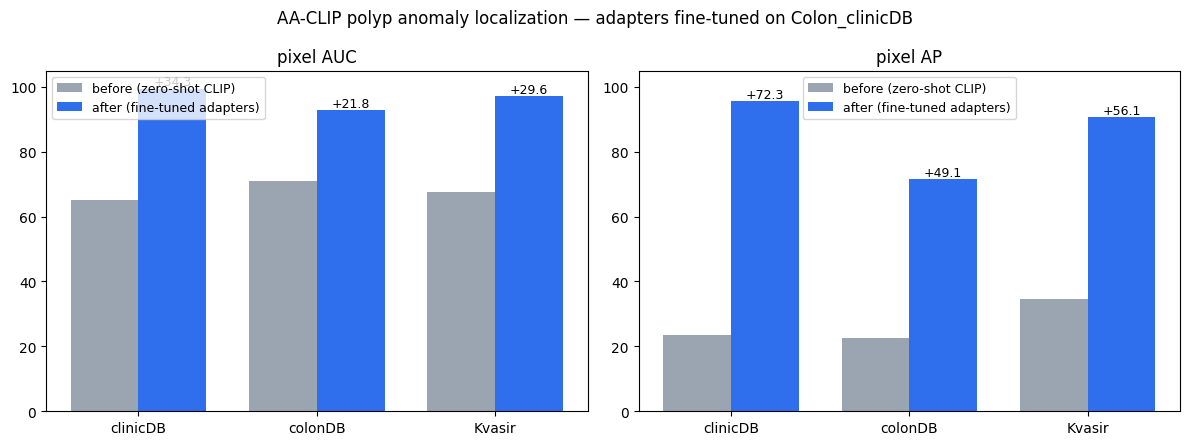

Chart saved to ./results_before_after/before_after.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

datasets = list(comp.index)
short = [d.replace("Colon_", "") for d in datasets]
x = np.arange(len(datasets))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ["pixel AUC", "pixel AP"]):
    b = comp[f"{metric} before"].values
    ax.bar(x - w / 2, b, w, label="before (zero-shot CLIP)", color="#9aa5b1")
    if f"{metric} after" in comp.columns:
        a = comp[f"{metric} after"].values
        ax.bar(x + w / 2, a, w, label="after (fine-tuned adapters)", color="#2f6fed")
        for xi, (bv, av) in enumerate(zip(b, a)):
            d = av - bv
            ax.text(xi + w / 2, av + 1, f"{d:+.1f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(short)
    ax.set_title(metric)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

fig.suptitle(f"AA-CLIP polyp anomaly localization — adapters fine-tuned on {TRAIN_DATASET}")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to {RESULTS_DIR}/before_after.png")

## 13. Visualize anomaly localization — before vs after, side by side

Each saved image is a vertical stack: **original / ground-truth overlay / predicted-heatmap overlay**. Left column = zero-shot CLIP, right column = fine-tuned model, same input image. (These were written during Sections 9 and 11 via `--vis_dir`.)

12 before / 12 after heatmaps found; showing 4 pairs


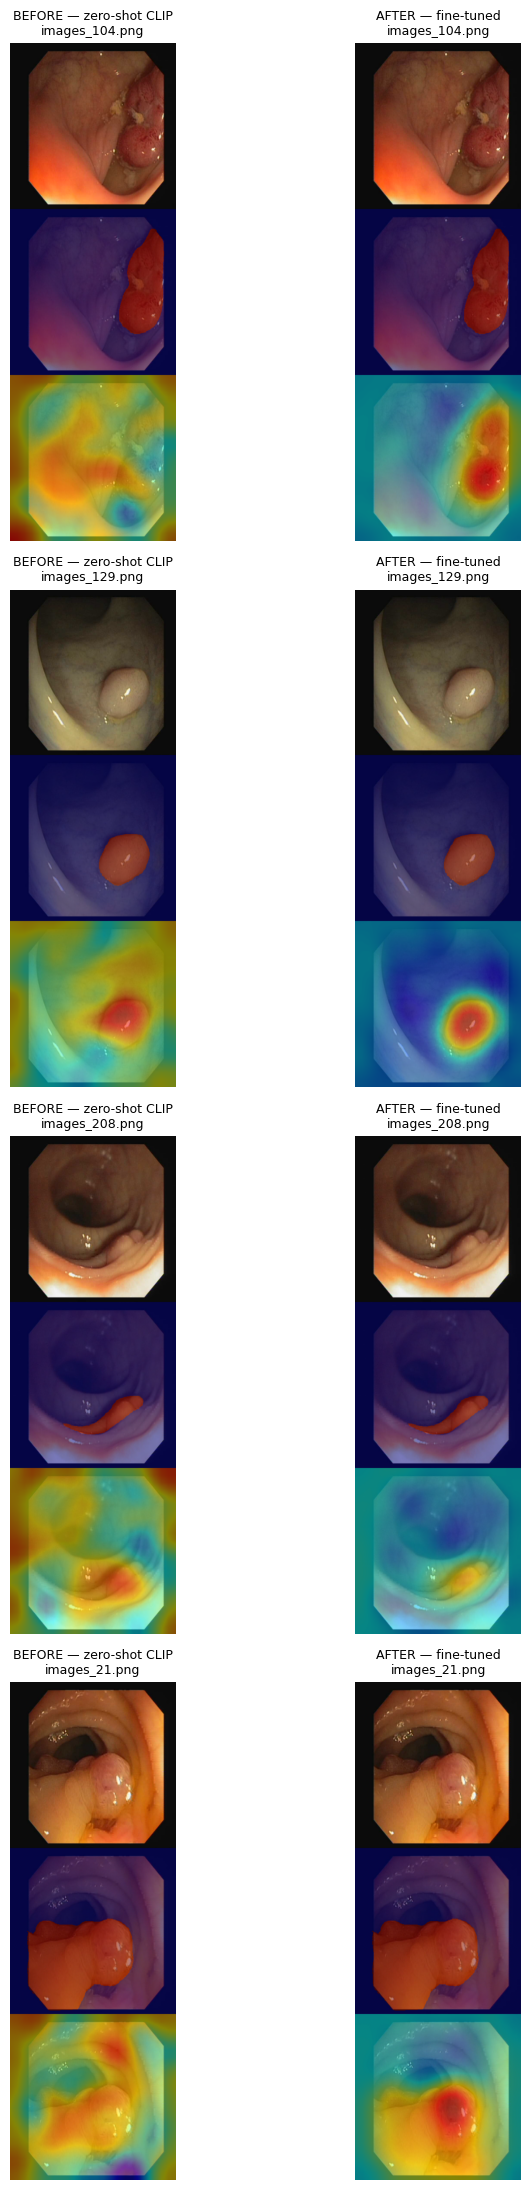

In [17]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

before_dir = f"{RESULTS_DIR}/vis_zero_shot/visualization/{TRAIN_DATASET}"
after_dir = f"{RESULTS_DIR}/vis_adapted/visualization/{TRAIN_DATASET}"

before_imgs = sorted(glob.glob(f"{before_dir}/**/*.png", recursive=True))
after_by_name = {os.path.basename(p): p
                 for p in glob.glob(f"{after_dir}/**/*.png", recursive=True)}
pairs = [(b, after_by_name[os.path.basename(b)])
         for b in before_imgs if os.path.basename(b) in after_by_name][:4]
print(f"{len(before_imgs)} before / {len(after_by_name)} after heatmaps found; showing {len(pairs)} pairs")

if pairs:
    fig, axes = plt.subplots(len(pairs), 2, figsize=(9, 5.5 * len(pairs)))
    axes = axes.reshape(len(pairs), 2)
    for row, (bp, ap) in enumerate(pairs):
        for col, (path, title) in enumerate([(bp, "BEFORE — zero-shot CLIP"),
                                             (ap, "AFTER — fine-tuned")]):
            axes[row, col].imshow(mpimg.imread(path))
            axes[row, col].set_title(f"{title}\n{os.path.basename(path)}", fontsize=9)
            axes[row, col].axis("off")
    plt.tight_layout()
    plt.show()

## 14. (Optional) Save checkpoints and results to Google Drive

Copies the trained adapters, all before/after CSVs, the comparison chart, and the heatmaps — everything you need for a report or video — so they survive the Colab session.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DEST = "/content/drive/MyDrive/aa-clip-results"
!mkdir -p {DRIVE_DEST}
!cp -r {SAVE_PATH} {DRIVE_DEST}/
!cp -r {RESULTS_DIR} {DRIVE_DEST}/
print("Copied checkpoints and before/after results to", DRIVE_DEST)

Mounted at /content/drive
Copied checkpoints and before/after results to /content/drive/MyDrive/aa-clip-results


## 15. (Optional) Run all bundled datasets back-to-back

Equivalent to the repo's `scripts.sh`, restricted to the datasets actually available in this repo.

*(Batch size fixed to 2 here — 16 OOMs on a T4, as noted in the training section.)*

In [ ]:
ALL_DATASETS = ["Colon_clinicDB", "Colon_colonDB", "Colon_Kvasir"]

for ds in ALL_DATASETS:
    sp = f"./ckpt/{ds}"
    os.makedirs(sp, exist_ok=True)
    print(f"\n=== Training {ds} ===")
    !python train.py --dataset {ds} --training_mode full_shot --save_path {sp} --text_epoch 5 --image_epoch 10 --image_batch_size 2 --img_size 336
    print(f"\n=== Testing {ds} ===")
    !python test.py --dataset {ds} --save_path {sp} --img_size 336


=== Training Colon_clinicDB ===

=== Testing Colon_clinicDB ===
100% 20/20 [01:21<00:00,  4.08s/it]
100% 20/20 [01:22<00:00,  4.12s/it]
100% 20/20 [01:22<00:00,  4.11s/it]
100% 20/20 [01:22<00:00,  4.11s/it]
100% 20/20 [01:22<00:00,  4.11s/it]
100% 20/20 [01:22<00:00,  4.15s/it]
100% 20/20 [01:22<00:00,  4.12s/it]
100% 20/20 [01:21<00:00,  4.09s/it]
100% 20/20 [01:22<00:00,  4.11s/it]
100% 20/20 [01:22<00:00,  4.12s/it]

=== Training Colon_colonDB ===
100% 24/24 [01:54<00:00,  4.79s/it]
100% 24/24 [01:51<00:00,  4.66s/it]
100% 24/24 [01:51<00:00,  4.66s/it]
100% 24/24 [01:51<00:00,  4.66s/it]
100% 24/24 [01:51<00:00,  4.66s/it]
100% 190/190 [02:41<00:00,  1.17it/s]
100% 190/190 [02:41<00:00,  1.17it/s]
100% 190/190 [02:41<00:00,  1.17it/s]
100% 190/190 [02:42<00:00,  1.17it/s]
100% 190/190 [02:42<00:00,  1.17it/s]
100% 190/190 [02:41<00:00,  1.18it/s]
100% 190/190 [02:42<00:00,  1.17it/s]
100% 190/190 [02:41<00:00,  1.17it/s]
100% 190/190 [02:42<00:00,  1.17it/s]
100% 190/190 [02:41<0